### Import Required Libraries 


In [295]:
#import libraries 
import pandas as pd
import numpy as np
# imprt warning for cleaner output
import warnings
warnings. filterwarnings('ignore')

### Load Dataset 

In [296]:
# Load dataset
df = pd.read_csv('bank-marketing.csv')


### Data Visualization

In [297]:
print("Shape:", df.shape) #dataset size

Shape: (45211, 17)


In [298]:
print("Missing Values:\n", df.isnull().sum()) #check missing values

Missing Values:
 V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
Class    0
dtype: int64


In [299]:
print(df['Class'].value_counts()) #count number of each class label occured
print(df['Class'].value_counts(normalize=True) * 100) #count percentage of each class label


Class
1    39922
2     5289
Name: count, dtype: int64
Class
1    88.30152
2    11.69848
Name: proportion, dtype: float64


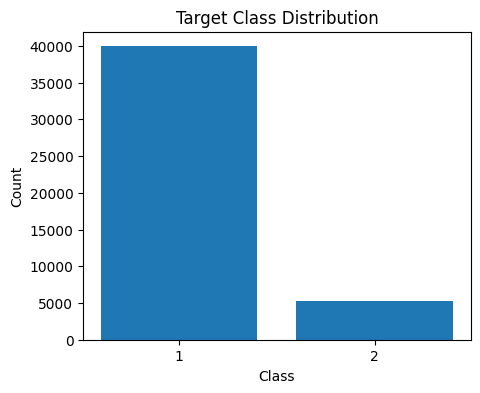

In [300]:
import matplotlib.pyplot as plt #import library 

counts = df['Class'].value_counts() #count class values 
plt.figure(figsize=(5,4)) #width and height of the graph 
plt.bar(counts.index.astype(str), counts.values) # shows class categoris in X-axis and count of the values in Y-axis

plt.title("Target Class Distribution") # gives the title to the bar graph 
plt.xlabel("Class") # gives the label to x-axis 
plt.ylabel("Count") # gives the label to y-axis
plt.show() # displays the bar chart 


### Data Preprocessing 

In [301]:
df['Class'] = df['Class'].replace({1: 0, 2: 1}) #replace 1-2 into 0-1
print("Unique values in Class:", df['Class'].unique()) #print unique class value 

Unique values in Class: [0 1]


In [302]:
# Sperate features and target 
X = df.drop('Class', axis=1) #feature
y = df['Class'] #target

In [303]:
from sklearn.preprocessing import LabelEncoder
# Encode categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str)) #convert text to numbers

In [304]:
X # view after encode categorial feature 

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,2,0,825,0,0,0,17,9,977,3,-1,0,3
45207,71,5,0,0,0,1729,0,0,0,17,9,456,2,-1,0,3
45208,72,5,1,1,0,5715,0,0,0,17,9,1127,5,184,3,2
45209,57,1,1,1,0,668,0,0,1,17,9,508,4,-1,0,3


In [305]:
y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: Class, Length: 45211, dtype: int64

### Data Splitting 

In [306]:
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split 
# Split the dataset intro training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling 

In [307]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # initialize the scaler
X_train_scaled = scaler.fit_transform(X_train) # fit scaler on traning data amd transform it
X_test_scaled = scaler.transform(X_test) # transform test data using the same scaler

In [308]:
X_train_scaled # view scaled X_train 

array([[ 0.00651495, -1.02057464, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [ 0.75993671,  1.42325035, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [ 0.10069267, -1.32605277, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       ...,
       [-0.65272909,  1.42325035, -1.9231057 , ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.74690681,  0.20133786, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.27601821, -1.02057464, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ]], shape=(36168, 16))

In [309]:
X_test_scaled # view scaled X_test

array([[-0.08766277, -1.02057464, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [ 0.57158127,  0.81229411,  1.36974507, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-1.50032857,  1.11777223,  1.36974507, ..., -0.41136376,
        -0.24477164,  0.445114  ],
       ...,
       [ 1.04246987, -1.32605277, -1.9231057 , ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.08766277, -1.32605277, -1.9231057 , ..., -0.41136376,
        -0.24477164,  0.445114  ],
       [-0.37019593,  1.42325035, -0.27668031, ..., -0.41136376,
        -0.24477164,  0.445114  ]], shape=(9043, 16))

### Model Selection: Logistic Regression 

In [310]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc,accuracy_score, classification_report
#Train logistic regression
logreg = LogisticRegression(class_weight='balanced') # balanced adjust weight and classes are treated fairly during training 
logreg.fit(X_train_scaled, y_train) # fit the model in X_train_scaled and y_train 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [311]:
y_test

3776     0
9928     0
33409    0
31885    0
15738    0
        ..
13353    0
38732    1
5654     0
3779     0
11677    0
Name: Class, Length: 9043, dtype: int64

In [312]:
# Predict class labels and prediction probabilities
y_pred = logreg.predict(X_test_scaled)
# Predict probability of positive class
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]  
# view y_pred_proba
y_pred_proba

array([0.07419714, 0.15305001, 0.30568459, ..., 0.06585329, 0.02286304,
       0.16024337], shape=(9043,))

### Model Evaluation 

In [313]:
# Evaluate Logistic Regression model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8041579121972796
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      7952
           1       0.36      0.81      0.50      1091

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.89      0.80      0.83      9043



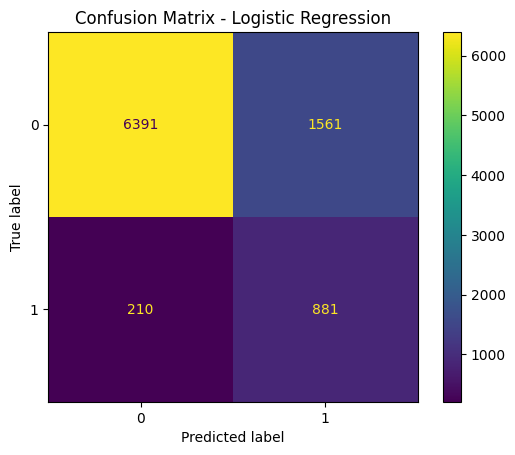

In [314]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# generate confusion matrix comparing acutal and predict labels 
cm = confusion_matrix(y_test, y_pred)
# Create confusion matrix display object
display = ConfusionMatrixDisplay(confusion_matrix=cm)
# plot the confusion matrix
display.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Final Visualization 

In [315]:
# calculate fpr, tpr and thresholds  
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
# compute AUC 
roc_auc = auc(fpr, tpr)

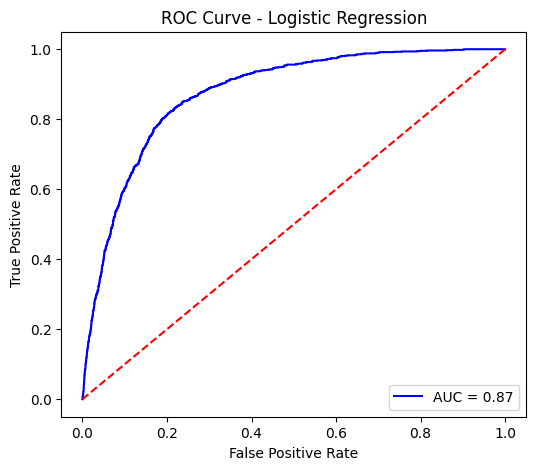

In [316]:
# create ROC curve plot 
plt.figure(figsize=(6,5))
# plot ROC Curve 
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # plot diagonal line 
# add plot title and axis labels 
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# display legend
plt.legend(loc='lower right')
# show the plot
plt.show()